# ReLU Varients
1. RelU
2. Leaky RelU
3. ELU
4. SELU
5. CELU

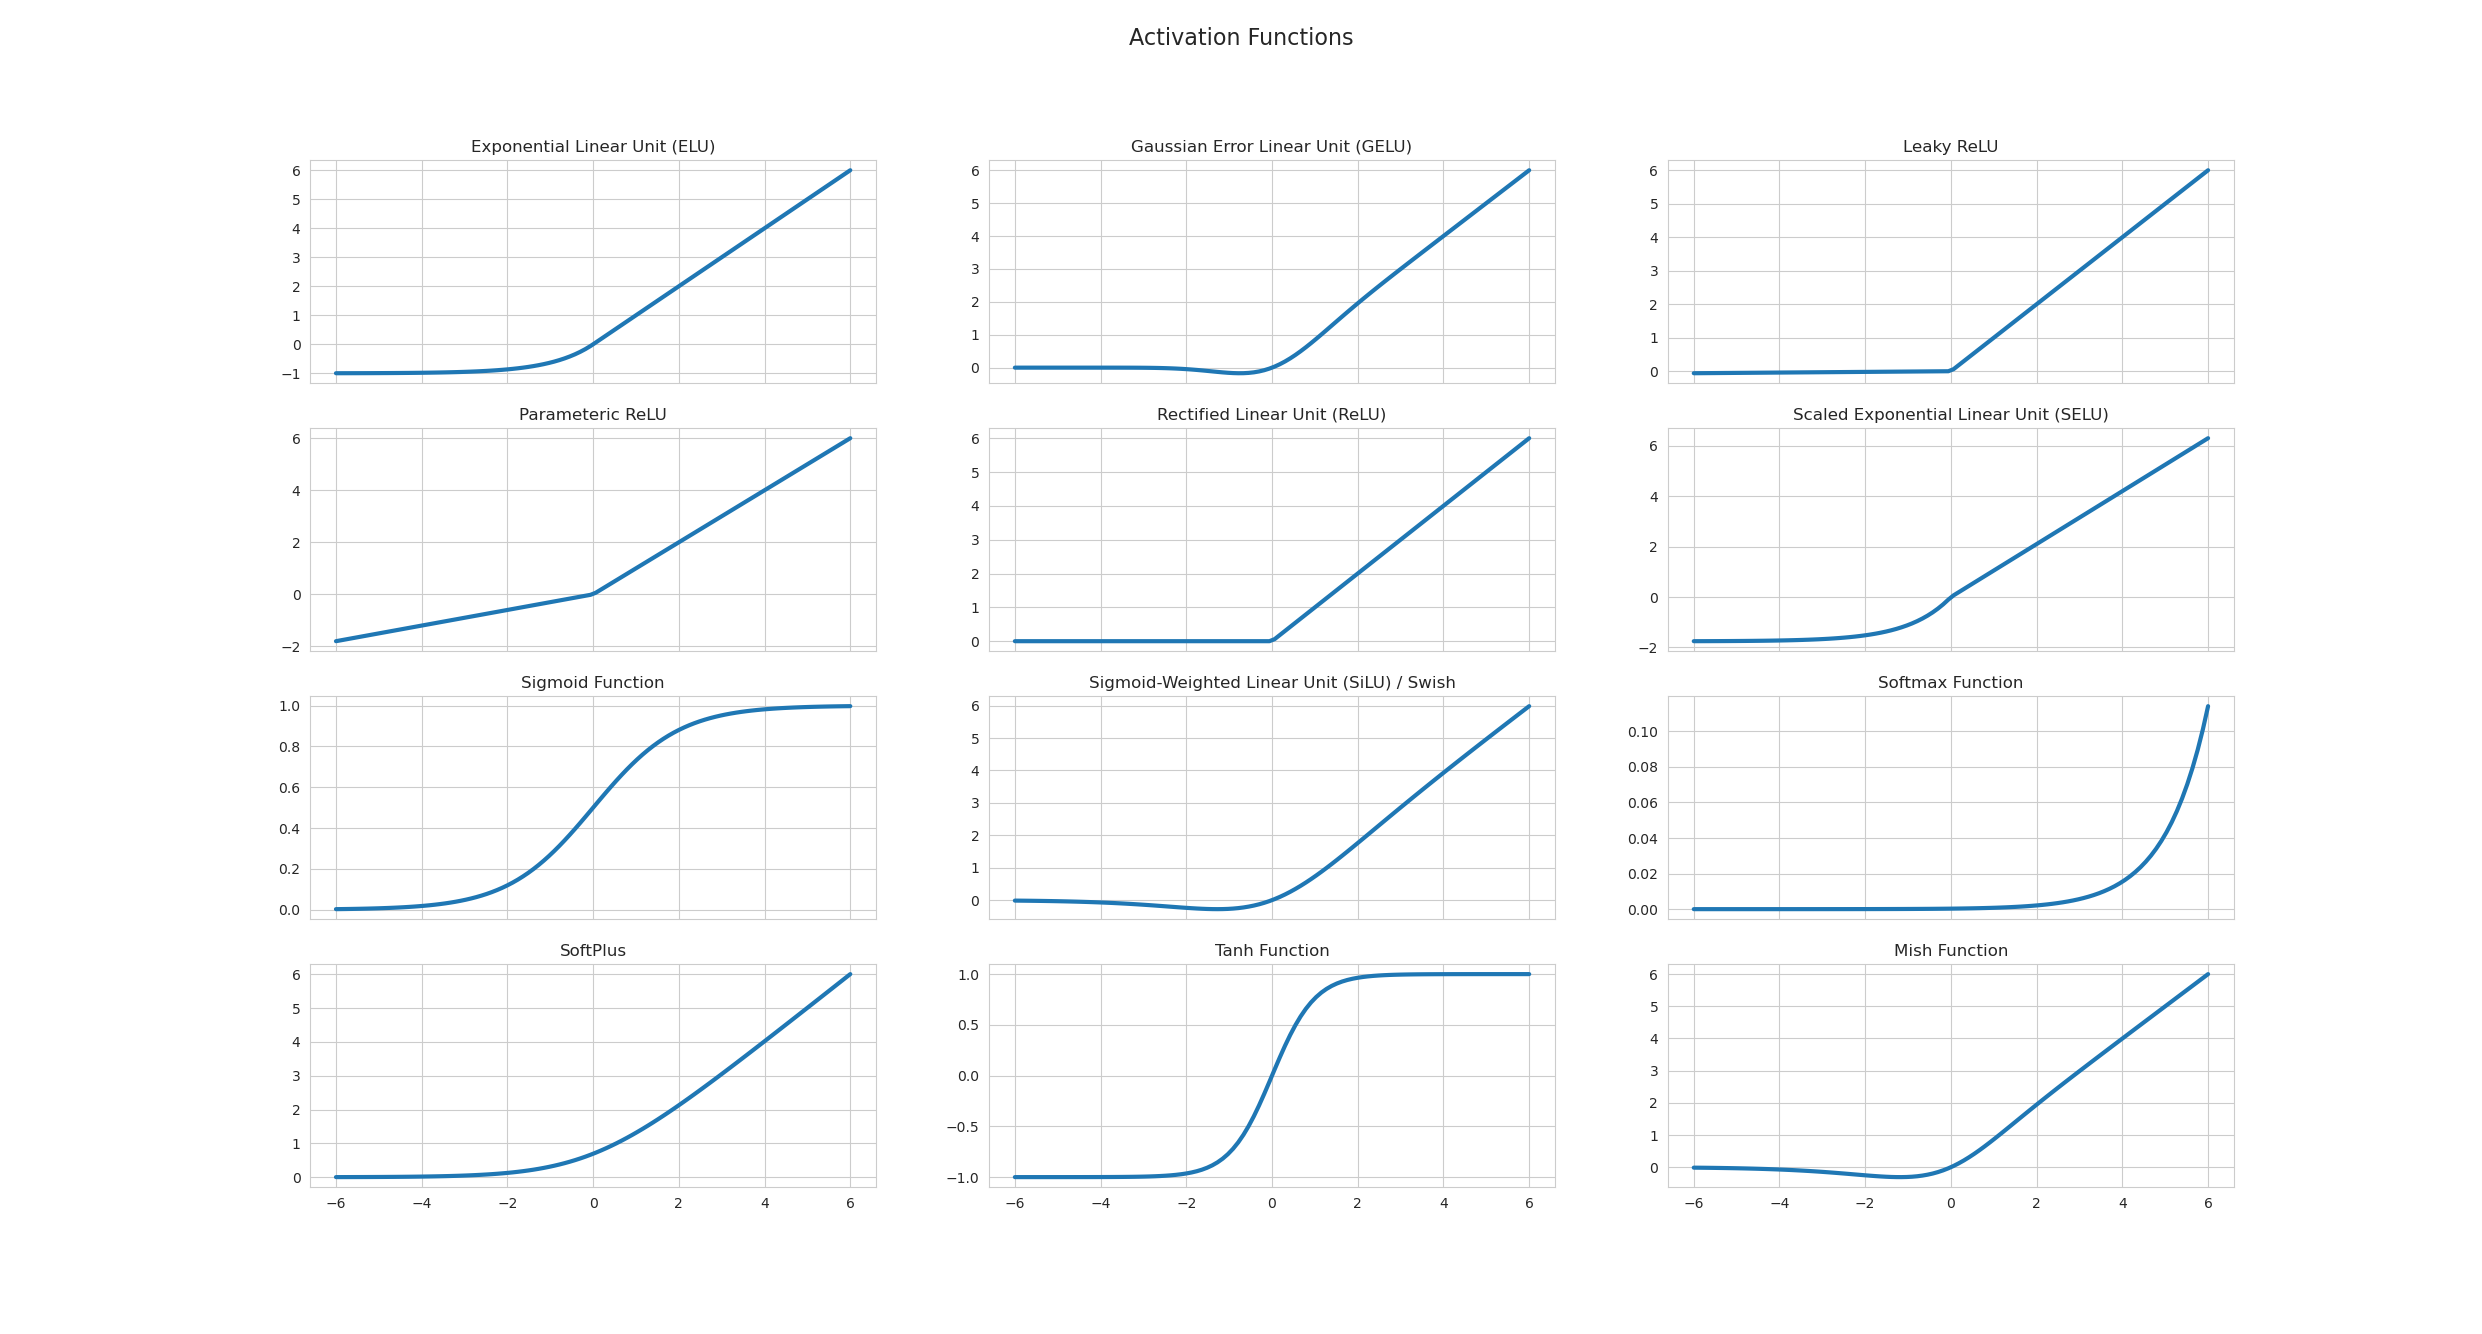

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from mlxtend.plotting import plot_decision_regions

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

In [4]:
from keras import Sequential
from keras.layers import Dense, Input
from keras.optimizers import Adam
from keras.activations import relu, celu, leaky_relu, elu, selu
from keras.losses import BinaryCrossentropy

from keras import regularizers

# Make Datasets

In [5]:
X, y = make_moons(n_samples=1000, noise=0.1, random_state=0)

# Plot Dataset

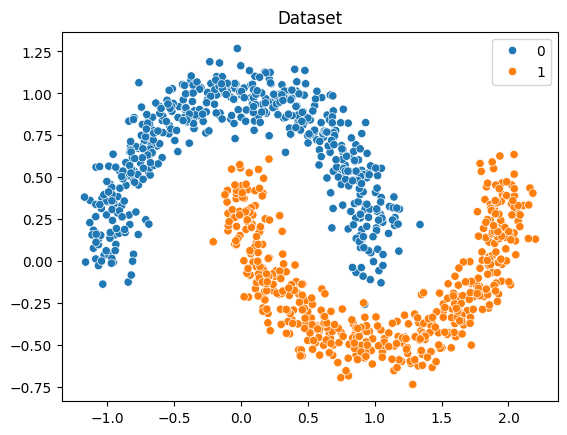

In [6]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)
plt.title('Dataset')
plt.show()

# Train Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Model

## Model Build

In [8]:
model = Sequential()
model.add(Input(shape=(2,)))

model.add(Dense(4, activation=relu, kernel_regularizer=regularizers.l2(0.01)))
model.add(Dense(8, activation=selu, kernel_regularizer=regularizers.l2(0.01)))
model.add(Dense(16, activation=celu, kernel_regularizer=regularizers.l2(0.01)))
model.add(Dense(8, activation=leaky_relu, kernel_regularizer=regularizers.l2(0.01)))
model.add(Dense(4, activation=elu, kernel_regularizer=regularizers.l2(0.01)))
model.add(Dense(1, activation='sigmoid'))

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 373 (1.46 KB)

 Trainable params: 373 (1.46 KB)

 Non-trainable params: 0 (0.00 B)

## Model Compile

In [10]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

## Model Training

In [12]:
%%time
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    verbose=0
)

CPU times: user 17.8 s, sys: 576 ms, total: 18.4 s
Wall time: 18.6 s


## Decision Region Plot

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


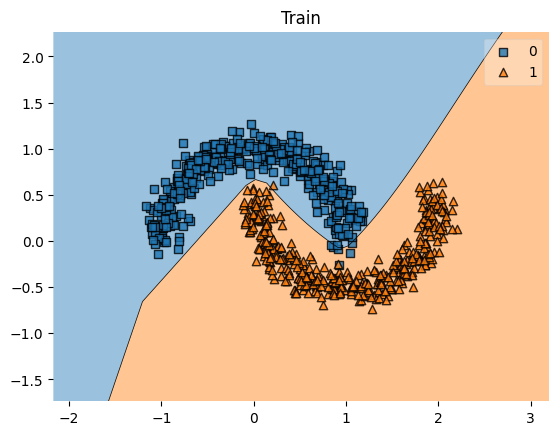

In [13]:
plot_decision_regions(X_train, y_train, clf=model)
plt.title('Train')
plt.show()

# Loss Plot

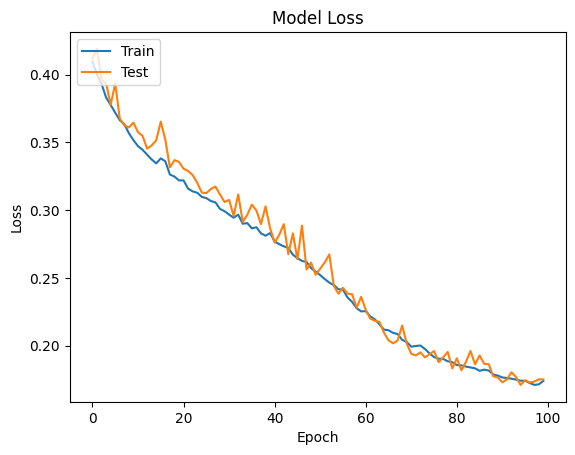

In [14]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Accuracy Plot

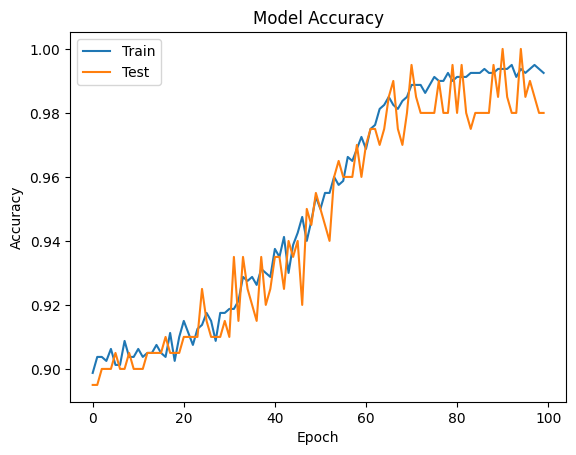

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')